# Worked Example: A Small Bioinformatics Notebook

This notebook is a compact demonstration of the practices covered in
[Chapter 4](../04-writing-good-notebooks.md): section headers that mirror
a paper, narration alongside code, and figures generated in place. The
"study" here is deliberately tiny — three short hypothetical coding
sequences — so you can focus on notebook mechanics rather than the
biology. Swap in your own sequences and the structure carries over
directly to a real project notebook.

**Study question:** Do these three candidate sequences differ enough in
GC content and translated product to be treated as distinct genes, or do
they look like near-duplicates?

## Data & Methods

### Environment

We record package versions up front, per the reproducibility guideline.

In [1]:
import Bio
import matplotlib
print("Biopython version:", Bio.__version__)
print("Matplotlib version:", matplotlib.__version__)

Biopython version: 1.88
Matplotlib version: 3.10.8


### Input sequences

Three short hypothetical open reading frames (ORFs). In a real project
this cell would instead load a FASTA file from your project folder, or
fetch records with `Bio.Entrez` — either way, the retrieval step belongs
in the notebook so the whole pipeline is reproducible from this file
alone.

In [2]:
from Bio.Seq import Seq

sequences = {
    "candidate_1": Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"),
    "candidate_2": Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAA"),
    "candidate_3": Seq("ATGCGTACGTTAGCTAGCTAGGGATCCGTACGTTAGCTA"),
}

for name, seq in sequences.items():
    print(f"{name}: {len(seq)} bp")

candidate_1: 39 bp
candidate_2: 39 bp
candidate_3: 39 bp


### Analysis steps

For each sequence we compute GC content and translate the ORF to its
predicted protein product. `Bio.Align`'s `PairwiseAligner` is the current
Biopython interface for alignment — the older `Bio.pairwise2` module is
deprecated and should not be used in new notebooks.

In [3]:
from Bio.SeqUtils import gc_fraction

gc_content = {name: round(gc_fraction(seq) * 100, 1) for name, seq in sequences.items()}
gc_content

{'candidate_1': 56.4, 'candidate_2': 53.8, 'candidate_3': 48.7}

In [4]:
proteins = {name: str(seq.translate(to_stop=True)) for name, seq in sequences.items()}
proteins

{'candidate_1': 'MAIVMGR', 'candidate_2': 'MAIVMGR', 'candidate_3': 'MRTLAS'}

In [5]:
from Bio.Align import PairwiseAligner

aligner = PairwiseAligner()
aligner.mode = "global"

score_1_2 = aligner.score(sequences["candidate_1"], sequences["candidate_2"])
score_1_3 = aligner.score(sequences["candidate_1"], sequences["candidate_3"])

print("Alignment score, candidate_1 vs candidate_2:", score_1_2)
print("Alignment score, candidate_1 vs candidate_3:", score_1_3)

Alignment score, candidate_1 vs candidate_2: 38.0
Alignment score, candidate_1 vs candidate_3: 13.0


## Results

**Figure 1** summarizes GC content across the three candidates.

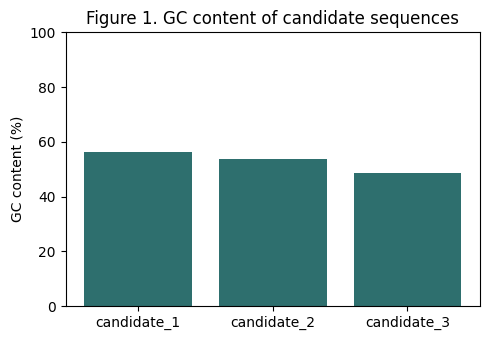

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(gc_content.keys(), gc_content.values(), color="#2e6f6e")
ax.set_ylabel("GC content (%)")
ax.set_title("Figure 1. GC content of candidate sequences")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

candidate_1 and candidate_2 differ by a single nucleotide near the stop codon (alignment score 38.0 out of a possible 39.0), and their GC content is close but not identical (56.4% vs. 53.8%). Because the differing base falls after the stop codon, the two still translate to the exact same protein, `MAIVMGR`. candidate_3 is clearly divergent in sequence (alignment score 13.0), GC content (48.7%), and translated product. This is consistent with candidate_1 and candidate_2 being alleles or a very recent duplication of the same gene, and candidate_3 being a distinct locus.

**Table 1** below reports the translated product for each candidate.

In [7]:
import pandas as pd

table1 = pd.DataFrame({
    "GC content (%)": gc_content,
    "Translated product": proteins,
})
table1

,GC content (%),Translated product
candidate_1,56.4,MAIVMGR
candidate_2,53.8,MAIVMGR
candidate_3,48.7,MRTLAS


candidate_1 and candidate_2 translate to the identical protein product, reinforcing the alignment result above, even though their nucleotide sequences and GC content are not quite identical.

## Discussion

This toy example illustrates the pattern to reuse for a real project: state the question, show the data and methods with brief narration, generate figures/tables in place, and close each result with a sentence of interpretation. Everything above ran from a fresh kernel start to finish, which is what "reproducible" means in practice — see [Chapter 3](../03-notebook-anatomy.md).